In [15]:

from collections import defaultdict
from dotenv import load_dotenv
import re

import pandas as pd

import nltk
from nltk.corpus import stopwords as nltk_stopwords
import spacy
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from keybert import KeyBERT

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import AgglomerativeClustering
from umap import UMAP
from hdbscan import HDBSCAN

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from docx import Document

In [9]:
load_dotenv('../.env.secret')

True

In [10]:
def get_review_df(filepath: str):
    df = pd.read_csv(filepath_or_buffer=filepath)
    if not ('rating' in df.columns) or not ('review' in df.columns):
        return f"CSV requires a 'rating' and 'review' column, has {df.columns} exiting.."
    return df[['rating', 'review']]

In [11]:
## Find It Fix It
# Apple
apple_findit = get_review_df('data/reviews/apple/FindItFixIt.csv')
apple_findit['app'] = 'FindItFixIt'
apple_findit['source'] = 'Apple'

# Google 
google_findit = get_review_df('data/reviews/google/FindItFixIt.csv')
google_findit['app'] = 'FindItFixIt'
google_findit['source'] = 'Google'

## San Jose 311
# Apple
apple_sj311 = get_review_df('data/reviews/apple/SanJose311.csv')
apple_sj311['app'] = 'SanJose311'
apple_sj311['source'] = 'Apple'

# Google
google_sj311 = get_review_df('data/reviews/google/SanJose311.csv')
google_sj311['app'] = 'SanJose311'
google_sj311['source'] = 'Google'

## See Click Fix
# Apple
apple_seeclick = get_review_df('data/reviews/apple/SeeClickFix.csv')
apple_seeclick['app'] = 'SeeClickFix'
apple_seeclick['source'] = 'Apple'

# Google
google_seeclick = get_review_df('data/reviews/google/SeeClickFix.csv')
google_seeclick['app'] = 'SeeClickFix'
google_seeclick['source'] = 'Google'

findit_df = pd.concat([apple_findit, google_findit], ignore_index=True)
sj311_df = pd.concat([apple_sj311, google_sj311], ignore_index=True)
seeclick_df = pd.concat([apple_seeclick, google_seeclick], ignore_index=True)

In [12]:
classifier = pipeline("text-classification", 
                       model="j-hartmann/emotion-english-distilroberta-base",
                       top_k=2)

def classify_text(text: str):
    return classifier(text)[0]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 27299.90it/s]


In [16]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'\n+', ' ', text)                   # collapse linebreaks
    text = re.sub(r'\s+', ' ', text)                   # collapse whitespace
    text = text.strip()                                # trim leading/trailing space
    return text

In [17]:
findit_df['review'] = findit_df['review'].map(normalize_text)
sj311_df['review'] = sj311_df['review'].map(normalize_text)
seeclick_df['review'] = seeclick_df['review'].map(normalize_text)

In [18]:
findit_df['sentiment'] = findit_df['review'].apply(classify_text)

In [19]:
sj311_df['sentiment'] = sj311_df['review'].apply(classify_text)

In [20]:
seeclick_df['sentiment'] = seeclick_df['review'].apply(classify_text)

In [ ]:
findit_df.to_csv("data/sentiment_analysis/Classified-FindItFixIt.csv")
sj311_df.to_csv("data/sentiment_analysis/Classified-SanJose311.csv")
seeclick_df.to_csv("data/sentiment_analysis/Classified-SeeClickFix.csv")


# EDA Questions
- What is a typical value?

- What is the uncertainty for a typical value?

- What is a good distributional fit for a set of numbers?

- What is a percentile?

- Does an engineering modification have an effect?

- Does a factor have an effect?

- What are the most important factors?

- Are measurements coming from different laboratories equivalent?

- What is the best function for relating a response variable to a set of factor variables?

- What are the best settings for factors?

- Can we separate signal from noise in time dependent data?

- Can we extract any structure from multivariate data?

- Does the data have outliers?

In [21]:
findit_mean = findit_df['rating'].mean()
findit_median = findit_df['rating'].median()
findit_mode = findit_df['rating'].mode()[0]

seeclick_mean = seeclick_df['rating'].mean()
seeclick_median = seeclick_df['rating'].median()
seeclick_mode = seeclick_df['rating'].mode()[0]

sj311_mean = sj311_df['rating'].mean()
sj311_median = sj311_df['rating'].median()
sj311_mode = sj311_df['rating'].mode()[0]

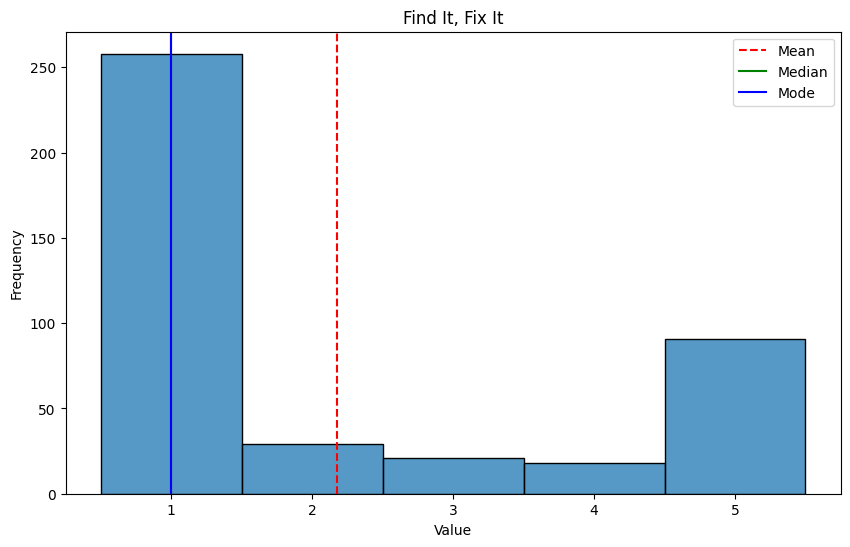

In [22]:
# FindItFixIt
plt.figure(figsize=(10, 6))
sns.histplot(data=findit_df, x="rating", bins=5, binrange=(1, 5), discrete=True)
plt.axvline(findit_mean, color='r', linestyle='--', label="Mean")
plt.axvline(findit_median, color='g', linestyle='-', label="Median")
plt.axvline(findit_mode, color='b', linestyle='-', label="Mode")

plt.title('Find It, Fix It')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.savefig("viz/FindItFixIt.png")
plt.show()

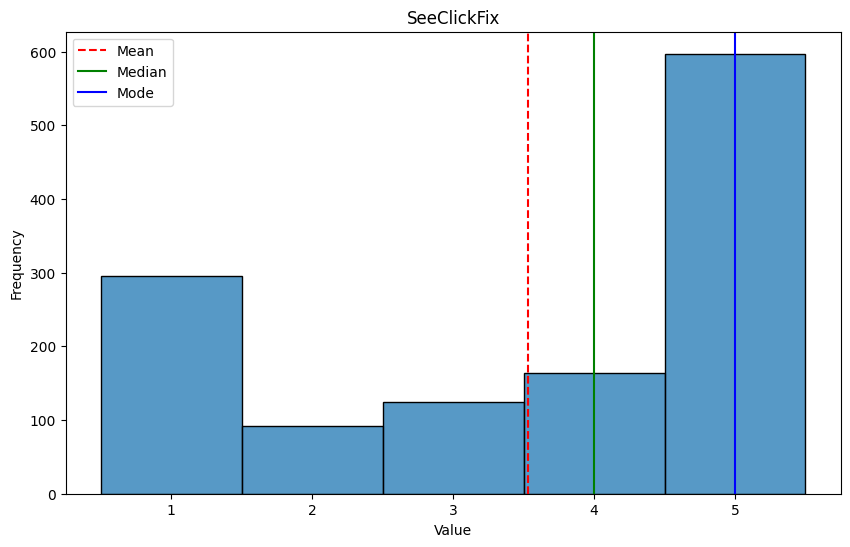

In [23]:
# SeeClickFix
plt.figure(figsize=(10, 6))
sns.histplot(data=seeclick_df, x="rating", bins=5, binrange=(1, 5), discrete=True)
plt.axvline(seeclick_mean, color='r', linestyle='--', label="Mean")
plt.axvline(seeclick_median, color='g', linestyle='-', label="Median")
plt.axvline(seeclick_mode, color='b', linestyle='-', label="Mode")

plt.title('SeeClickFix')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.savefig("viz/SeeClickFix.png")
plt.show()

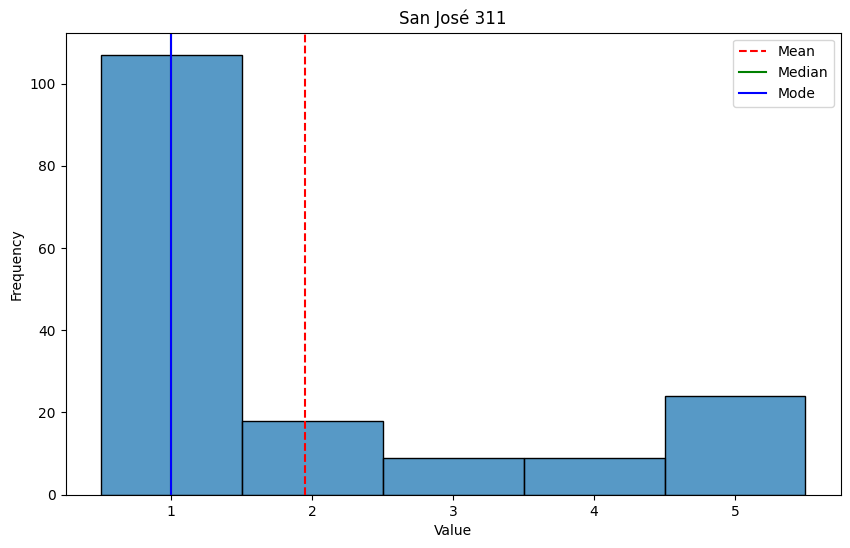

In [24]:
# San José 311
plt.figure(figsize=(10, 6))
sns.histplot(data=sj311_df, x="rating", bins=5, binrange=(1, 5), discrete=True)
plt.axvline(sj311_mean, color='r', linestyle='--', label="Mean")
plt.axvline(sj311_median, color='g', linestyle='-', label="Median")
plt.axvline(sj311_mode, color='b', linestyle='-', label="Mode")

plt.title('San José 311')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.savefig("viz/SanJose311.png")
plt.show()

In [25]:
combined_df = pd.concat([findit_df, sj311_df, seeclick_df], ignore_index=True)

In [26]:
combined_df["top_emotion"] = combined_df["sentiment"].apply(lambda x: x[0]['label'])

In [27]:
combined_mean = combined_df['rating'].mean()
combined_median = combined_df['rating'].median()
combined_mode = combined_df['rating'].mode()[0]

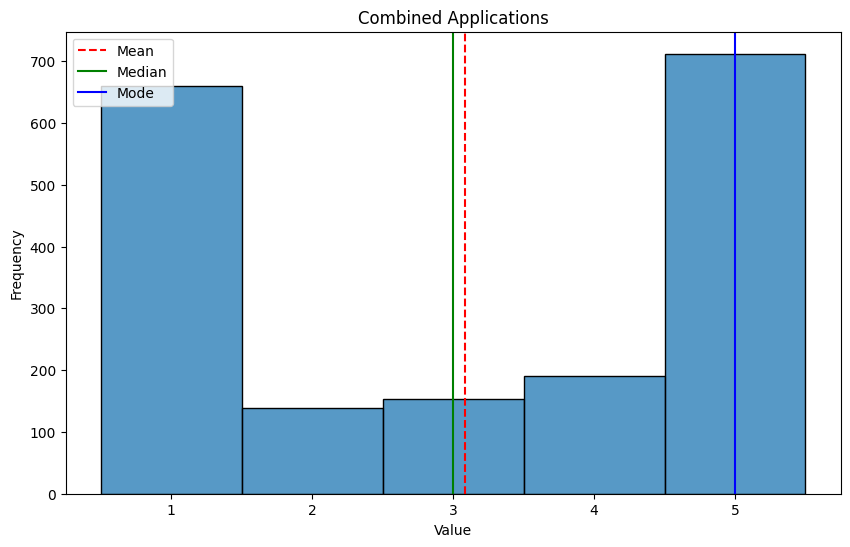

In [28]:
# Combined Dataset
plt.figure(figsize=(10, 6))
sns.histplot(data=combined_df, x="rating", bins=5, binrange=(1, 5), discrete=True)
plt.axvline(combined_mean, color='r', linestyle='--', label="Mean")
plt.axvline(combined_median, color='g', linestyle='-', label="Median")
plt.axvline(combined_mode, color='b', linestyle='-', label="Mode")

plt.title('Combined Applications')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.savefig("viz/CombinedApps.png")
plt.show()

In [29]:
findit_text = " ".join(review for review in findit_df["review"])
seeclick_text = " ".join(review for review in seeclick_df["review"])
sj311_text = " ".join(review for review in sj311_df["review"])
combined_text = " ".join(review for review in combined_df["review"])

In [ ]:
app_specific_stopwords = {'report', 'reporting', 'city', 'town', 'apple', 'google', 'seattle', 'san jose', 'app', 'homeless', 'people', 'homeless people'}
nltk.download('stopwords')

# NLTK
nltk_stops = set(nltk_stopwords.words('english'))

# spaCy
nlp = spacy.load('en_core_web_sm')
spacy_stops = nlp.Defaults.stop_words

# Combined
stop_words = nltk_stops.union(spacy_stops).union(app_specific_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/svitlana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


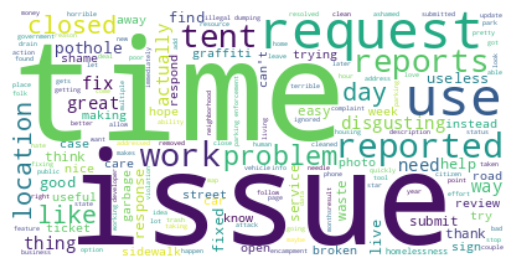

In [32]:
wordcloud = WordCloud(stopwords=stop_words, background_color="white").generate(findit_text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("viz/WordCloud-FindItFixIt.png")
plt.show()

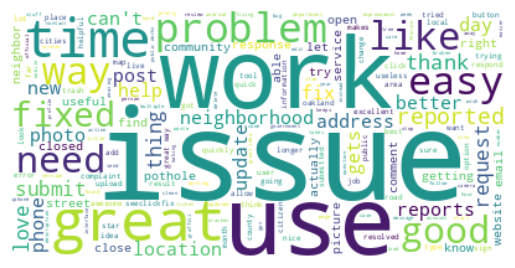

In [33]:
wordcloud = WordCloud(stopwords=stop_words, background_color="white").generate(seeclick_text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("viz/Wordcloud-SeeClickFix.png")
plt.show()

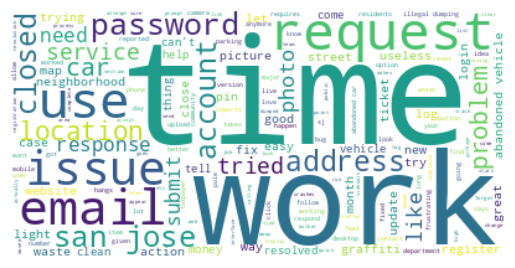

In [34]:
wordcloud = WordCloud(stopwords=stop_words, background_color="white").generate(sj311_text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("viz/Wordcloud-SanJose311.png")
plt.show()

In [35]:
def preprocess_for_topics(text):
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop        # remove spacy stopwords
        and not token.is_punct      # remove punctuation
        and not token.like_num      # remove numbers
        and token.is_alpha          # only keep actual words
        and token.lemma_.lower() not in stop_words  # also remove nltk stopwords
    ]
    return " ".join(tokens)

combined_df["normalized_review"] = combined_df["review"].apply(preprocess_for_topics)

In [36]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    cluster_selection_method='eom',
    prediction_data=True
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    min_topic_size=20,
    calculate_probabilities=True
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5791.27it/s]


In [37]:
combined_topics, combined_probs = topic_model.fit_transform(combined_df["normalized_review"])

In [38]:
# See what themes emerged
all_topics = topic_model.get_topic_info()
topic_map = dict(zip(all_topics['Topic'], all_topics['Name']))
combined_df["theme"] = combined_topics
combined_df["theme"] = combined_df["theme"].map(topic_map)

In [39]:
findit_negatives = combined_df[(combined_df['rating'] <= 2) & (combined_df['app'] == 'FindItFixIt')]
findit_positives = combined_df[(combined_df['rating'] >= 4) & (combined_df['app'] == 'FindItFixIt')]
len(findit_negatives), len(findit_positives)

(287, 109)

In [40]:
seeclick_negatives = combined_df[(combined_df['rating'] <= 2) & (combined_df['app'] == 'SeeClickFix')]
seeclick_positives = combined_df[(combined_df['rating'] >= 4) & (combined_df['app'] == 'SeeClickFix')]
len(seeclick_negatives), len(seeclick_positives)

(388, 761)

In [41]:
sj311_negatives = combined_df[(combined_df['rating'] <= 2) & (combined_df['app'] == 'SanJose311')]
sj311_positives = combined_df[(combined_df['rating'] >= 4) & (combined_df['app'] == 'SanJose311')]
len(sj311_negatives), len(sj311_positives)

(125, 33)

# Negative:Positive Ratio Per App
Find It, Fix It = `2.6 : 1`

SeeClickFix = `1 : 1.9`

San José 311 = `3.8 : 1`

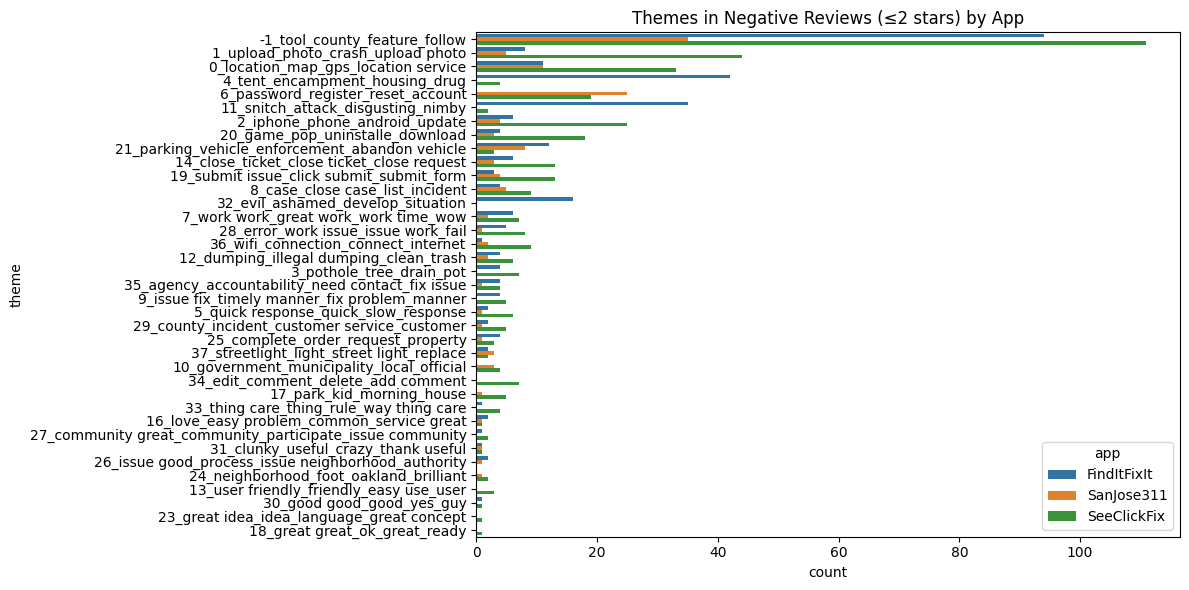

In [42]:
all_negatives = combined_df[combined_df['rating'] <= 2]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=all_negatives,
    y='theme',
    hue='app',
    order=all_negatives['theme'].value_counts().index
)
plt.title('Themes in Negative Reviews (≤2 stars) by App')
plt.tight_layout()
plt.show()

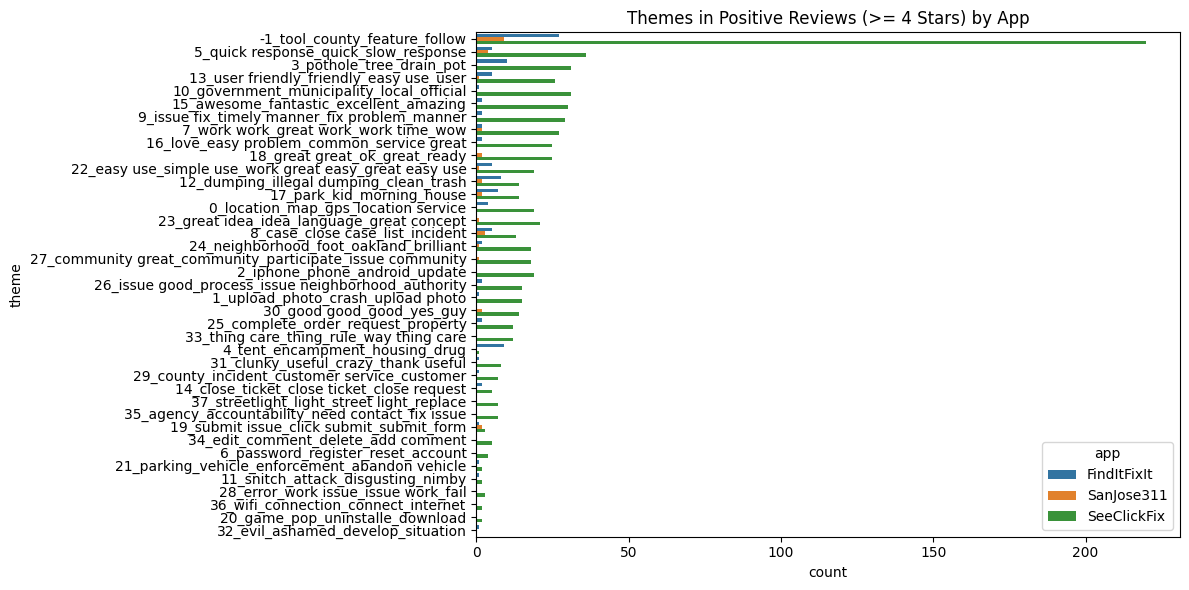

In [43]:
all_positives = combined_df[combined_df['rating'] >= 4]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=all_positives,
    y='theme',
    hue='app',
    order=all_positives['theme'].value_counts().index
)
plt.title('Themes in Positive Reviews (>= 4 Stars) by App')
plt.tight_layout()
plt.show()

In [44]:
negative_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85
)

negative_topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=negative_vectorizer,
    ctfidf_model=ctfidf_model,
    min_topic_size=20,
    calculate_probabilities=True
)

In [45]:
negative_subset = all_negatives
negative_topics, negative_probs = negative_topic_model.fit_transform(negative_subset["normalized_review"])

In [46]:
# Negative Themes
all_negative_topics = negative_topic_model.get_topic_info()
negative_topic_map = dict(zip(all_negative_topics['Topic'], all_negative_topics['Name']))
negative_subset["theme"] = negative_topics
negative_subset["theme"] = negative_subset["theme"].map(negative_topic_map)
len(negative_subset)

800

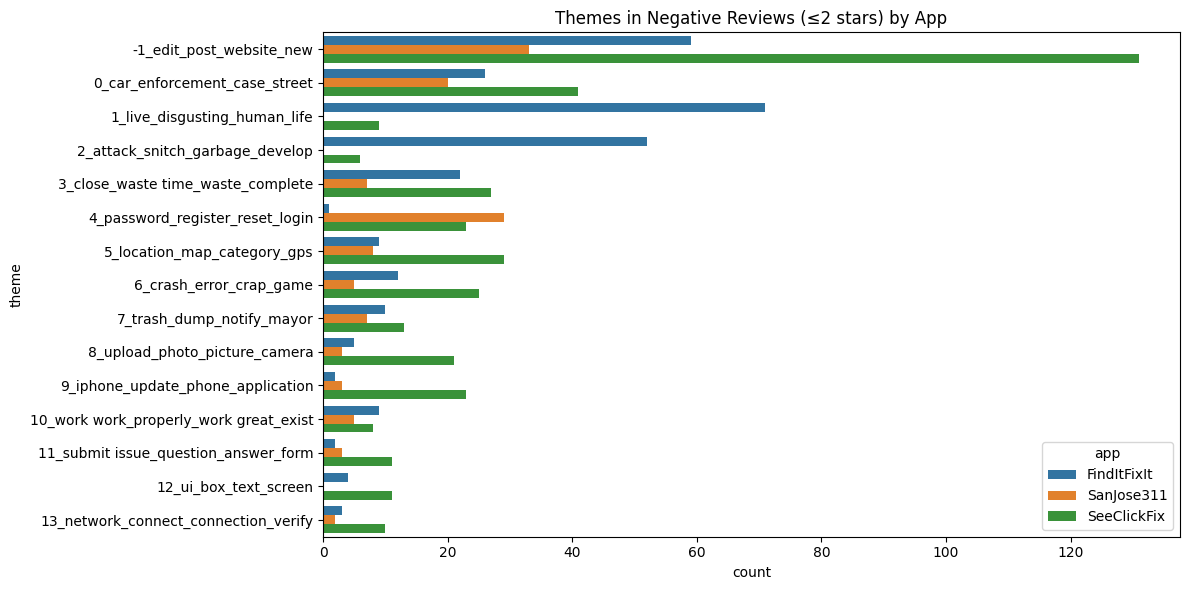

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=negative_subset,
    y='theme',
    hue='app',
    order=negative_subset['theme'].value_counts().index
)
plt.title('Themes in Negative Reviews (≤2 stars) by App')
plt.tight_layout()
plt.savefig("viz/NegativeThemes.png")
plt.show()

In [48]:
positive_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85
)

positive_topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=positive_vectorizer,
    ctfidf_model=ctfidf_model,
    min_topic_size=20,
    calculate_probabilities=True
)

In [49]:
positive_subset = all_positives
positive_topics, positive_probs = positive_topic_model.fit_transform(positive_subset["normalized_review"])

In [50]:
# Positive Themes
all_positive_topics = positive_topic_model.get_topic_info()
positive_topic_map = dict(zip(all_positive_topics['Topic'], all_positive_topics['Name']))
positive_subset["theme"] = positive_topics
positive_subset["theme"] = positive_subset["theme"].map(positive_topic_map)
len(positive_subset)

903

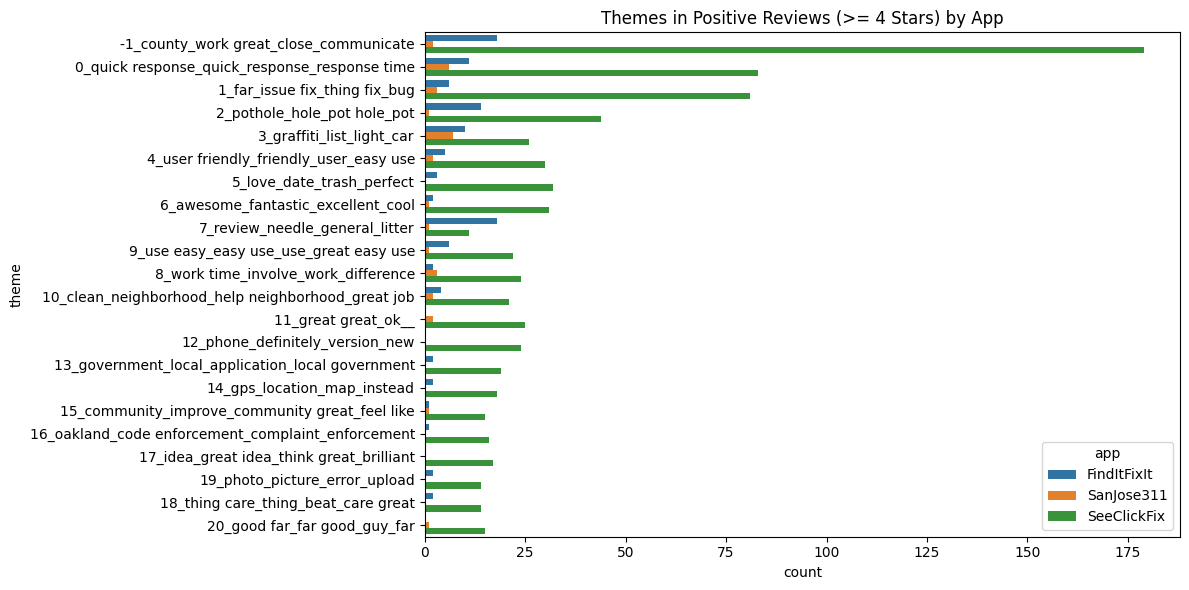

In [51]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=positive_subset,
    y='theme',
    hue='app',
    order=positive_subset['theme'].value_counts().index
)
plt.title('Themes in Positive Reviews (>= 4 Stars) by App')
plt.tight_layout()
plt.savefig("viz/PositiveThemes.png")
plt.show()

In [ ]:
negative_subset.to_csv("data/sentiment_analysis/NegativeSubset.csv")
positive_subset.to_csv("data/sentiment_analysis/PositiveSubset.csv")

In [52]:
# Percentage of <=2 Star Reviews - Find It, Fix It
len(findit_df[findit_df['rating'] <= 2])/len(findit_df)


0.6882494004796164

In [53]:
# Percentage of <=2 Star Reviews - SeeClickFix
len(seeclick_df[seeclick_df['rating'] <= 2])/len(seeclick_df)


0.30479183032207385

In [54]:
# Percentage of <=2 Star Reviews - San José 311
len(sj311_df[sj311_df['rating'] <= 2])/len(sj311_df)

0.7485029940119761

In [55]:
negative_subset["top_sentiment"] = negative_subset["sentiment"].apply(lambda x: x[0])
positive_subset["top_sentiment"] = positive_subset["sentiment"].apply(lambda x: x[0])

In [ ]:

kw_model = KeyBERT(model="all-mpnet-base-v2")  # reuse same embedding model

def extract_keyphrases(text):
    if not isinstance(text, str) or not text.strip():
        return []
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),  # single words and bigrams
        stop_words='english',
        top_n=3                        # keyphrases per review
    )
    return [kw[0] for kw in keywords] 


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6196.48it/s]


In [57]:
negative_subset["key_phrases"] = negative_subset["normalized_review"].apply(extract_keyphrases)
positive_subset["key_phrases"] = positive_subset["normalized_review"].apply(extract_keyphrases)

In [58]:
# Get all unique phrases
all_negative_phrases = list(set([
    phrase
    for phrases in negative_subset['key_phrases']
    for phrase in phrases
    if isinstance(phrases, list)
]))

# Embed them
embedder = SentenceTransformer("all-mpnet-base-v2")
embeddings = embedder.encode(all_negative_phrases)

# Cluster
clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.7,  # lower = more clusters, higher = fewer
    metric='cosine',
    linkage='average'
)
labels = clustering.fit_predict(embeddings)

# Build grouped output
negative_phrase_clusters = defaultdict(list)
for phrase, label in zip(all_negative_phrases, labels):
    negative_phrase_clusters[label].append(phrase)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6491.62it/s]


In [59]:
# Create a DOCX file for easier table portability
rows = {}
for cluster, phrases in (sorted(negative_phrase_clusters.items(), key=lambda x: len(x[1]), reverse=True)[:15]):
        rows[f"Cluster {cluster}"] = phrases

phrases_df = pd.DataFrame({'Cluster': list(rows.keys()), 'Phrases': list(rows.values())})
phrases_df

doc = Document()

table = doc.add_table(rows=1, cols=len(phrases_df.columns))

header = doc.sections[0].header
header_para = header.paragraphs[0]
header_para.text = 'Negative Review Phrase Clusters'

for index, row in phrases_df.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

doc.save('data/sentiment_analysis/NegativePhraseClusters.docx')

In [60]:
# Get all unique phrases
all_positive_phrases = list(set([
    phrase
    for phrases in positive_subset['key_phrases']
    for phrase in phrases
    if isinstance(phrases, list)
]))

# Embed them
embedder = SentenceTransformer("all-mpnet-base-v2")
embeddings = embedder.encode(all_positive_phrases)

# Cluster
clustering = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.8,  # lower = more clusters, higher = fewer
    metric='cosine',
    linkage='average'
)
labels = clustering.fit_predict(embeddings)

# Build grouped output
positive_phrase_clusters = defaultdict(list)
for phrase, label in zip(all_positive_phrases, labels):
    positive_phrase_clusters[label].append(phrase)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2543.52it/s]


In [61]:
# Create a DOCX file for easier table portability - TODO: deduplicate
rows = {}
for cluster, phrases in (sorted(positive_phrase_clusters.items(), key=lambda x: len(x[1]), reverse=True)[:15]):
        rows[f"Cluster {cluster}"] = phrases

phrases_df = pd.DataFrame({'Cluster': list(rows.keys()), 'Phrases': list(rows.values())})
phrases_df
# Create a new Document
doc = Document()

# Add a table to the document
table = doc.add_table(rows=1, cols=len(phrases_df.columns))

# Access the header section
header = doc.sections[0].header
header_para = header.paragraphs[0]
header_para.text = 'Positive Review Phrase Clusters'

# Add the data rows
for index, row in phrases_df.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Save the document
doc.save('data/sentiment_analysis/PositivePhraseClusters.docx')

In [62]:
combined_df['sentiment'].unique

<bound method Series.unique of 0       [{'label': 'surprise', 'score': 0.371869891881...
1       [{'label': 'sadness', 'score': 0.7127492427825...
2       [{'label': 'sadness', 'score': 0.9845277667045...
3       [{'label': 'surprise', 'score': 0.691125273704...
4       [{'label': 'anger', 'score': 0.838695466518402...
                              ...                        
1852    [{'label': 'sadness', 'score': 0.7304388880729...
1853    [{'label': 'surprise', 'score': 0.599222421646...
1854    [{'label': 'neutral', 'score': 0.4986288845539...
1855    [{'label': 'surprise', 'score': 0.711148858070...
1856    [{'label': 'joy', 'score': 0.9144654273986816}...
Name: sentiment, Length: 1857, dtype: object>